In [1]:
import numpy as np
import pandas as pd
from scipy.io import mmread

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 6)

import anndata as ad
import scanpy as sc
import seaborn as sns
import os
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans


In [2]:
dfpro = pd.read_csv('../data/20250305_all_CarcVsSarc_k=14_n=15_withClinical.csv')
dfpro = dfpro.assign(
    tma_fov = dfpro['TMA.y'].astype(str) + '_' + dfpro['FOV_RNA'].astype(str)
)

/var/folders/3_/pf5ff_p57fqfsm6w00s_hg480000gn/T/ipykernel_83996/1261231823.py:1: DtypeWarning: Columns (80,93,96,97,99,100,101,102,107,109,115,116,131,132,133,134,135,136,137,141,142,144,145,147,148,149,151,152,153,155,156,158,159,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  dfpro = pd.read_csv('../data/20250305_all_CarcVsSarc_k=14_n=15_withClinical.csv')


In [3]:
# change local xy to global xy
dfpro['global_x'] = 0
dfpro['global_y'] = 0

i = 0
fovlist = np.unique(dfpro['tma_fov']).tolist()
fovlistss = [x for x in sorted(fovlist, key = int)]

for fov in fovlistss:
    dfpro.loc[dfpro.tma_fov == fov,'global_x']  = 10000*i + dfpro.loc[dfpro.tma_fov == fov,'X_cent_x']
    dfpro.loc[dfpro.tma_fov == fov,'global_y']  = 10000*i + dfpro.loc[dfpro.tma_fov == fov,'Y_cent_x']
    i = i + 1

In [4]:
def get_spatial_knn_indices(locations, n_neighbors=5, method='kd_tree'):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm=method)
    nbrs.fit(locations)
    _, knn_idx = nbrs.kneighbors(locations)
    return knn_idx  # shape (n_cells, k)

def compute_cn_adjacency(df, k=5, method='kd_tree', binary=False):
    """
    """
    # 1) get knn
    coords    = df[['global_x','global_y']].values # hard coded lol
    knn_idx   = get_spatial_knn_indices(coords, n_neighbors=k, method=method)
    cn_labels = df['cluster_composition'].astype(str).values
    unique_cn = np.unique(cn_labels)
    
    # 2) initialize accumulators
    N = {cn: (cn_labels==cn).sum() for cn in unique_cn}
    count_matrix = pd.DataFrame(0, index=unique_cn, columns=unique_cn, dtype=float)
    incidence_matrix = pd.DataFrame(0, index=unique_cn, columns=unique_cn, dtype=float)
    
    # 3) loop over each cell
    for i, src in enumerate(cn_labels):
        neigh  = cn_labels[knn_idx[i]]      # e.g. array of length k
        dsts, cnts = np.unique(neigh, return_counts=True)
        for dst, cnt in zip(dsts, cnts):
            count_matrix.loc[src, dst] += cnt
            if binary and cnt>0:
                incidence_matrix.loc[src, dst] += 1
    
    # 4) normalize
    A = count_matrix.div(pd.Series(N), axis=0)      # average counts per source cell
    if binary:
        B = incidence_matrix.div(pd.Series(N), axis=0)  # fraction of source cells that see dst
        return A, B
    else:
        return A

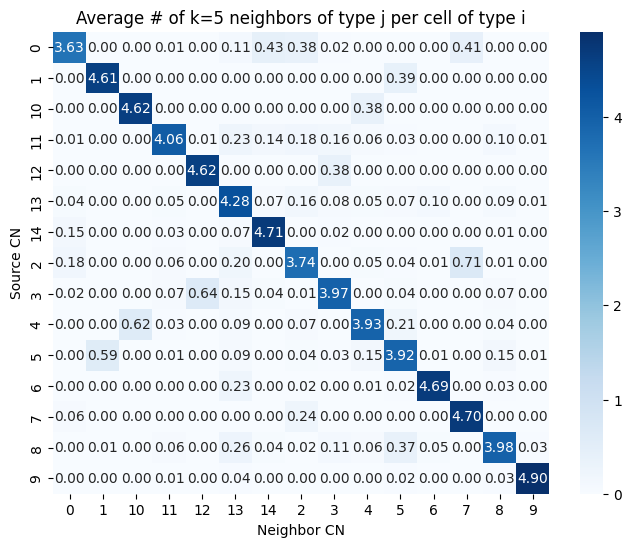

In [5]:
A, B = compute_cn_adjacency(dfpro, k=5, method='kd_tree', binary=True)

# You can then plot A as a heatmap:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(A.astype(float), cmap="Blues", annot=True, fmt=".2f")
plt.xlabel("Neighbor CN")
plt.ylabel("Source CN")
plt.title("Average # of k=5 neighbors of type j per cell of type i")
plt.show()


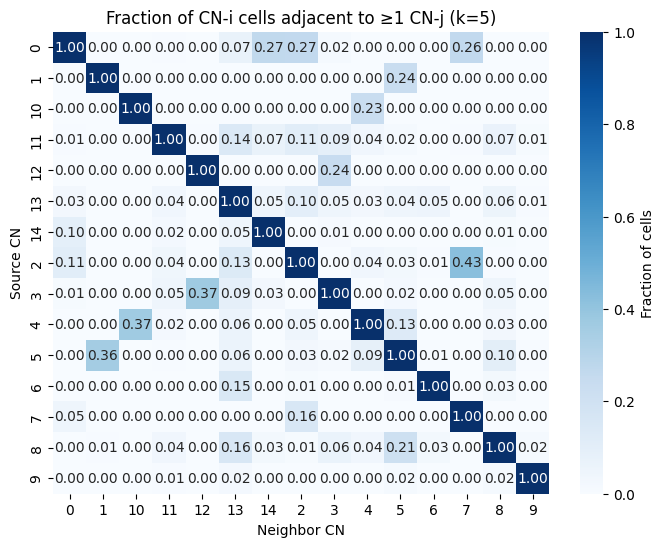

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(B, cmap="Blues", annot=True, fmt=".2f",
            cbar_kws={"label": "Fraction of cells"})
plt.xlabel("Neighbor CN")
plt.ylabel("Source CN")
plt.title("Fraction of CN-i cells adjacent to ≥1 CN-j (k=5)")
plt.show()

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# --- compute B as before ---
def get_spatial_knn_indices(locations, n_neighbors=5, method='kd_tree'):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm=method)
    nbrs.fit(locations)
    _, knn_idx = nbrs.kneighbors(locations)
    return knn_idx

def compute_cn_incidence(df, k=5, method='kd_tree'):
    coords    = df[['global_x','global_y']].values
    knn_idx   = get_spatial_knn_indices(coords, n_neighbors=k, method=method)
    cn_labels = df['cluster_composition'].astype(str).values
    unique_cn = np.unique(cn_labels)

    N = {cn: (cn_labels==cn).sum() for cn in unique_cn}
    incidence = pd.DataFrame(0, index=unique_cn, columns=unique_cn, dtype=float)
    for i, src in enumerate(cn_labels):
        neigh = cn_labels[knn_idx[i]]
        for dst in np.unique(neigh):
            incidence.loc[src, dst] += 1
    return incidence.div(pd.Series(N), axis=0)

B = compute_cn_incidence(dfpro, k=5)


In [35]:
threshold = 0.05
# --- build graph with threshold ---
G = nx.DiGraph()
for src in B.index:
    for dst in B.columns:
        w = B.loc[src, dst]
        if w >= threshold:      # only edges ≥5%
            G.add_edge(src, dst, weight=w)


# Glasbey palette (slice to number of nodes)
glasbey15 = [
    "#e31a1c","#6a3d9a","#009900","#00cccc","#ccff00",
    "#ff6699","#7f007f","#ff7f00","#660000","#006d2c",
    "#1f78b4","#b2df8a","#a6cee3","#ffff99","#cab2d6",
]
nodes = sorted(G.nodes(),key=int)
node_colors = [glasbey15[i] for i in range(len(nodes))]

# --- layout and drawing parameters ---
pos = nx.circular_layout(G)

# edge weights & colormap
weights = np.array([G[u][v]['weight'] for u,v in G.edges()])
# normalize weights to [0,1]
norm = mpl.colors.Normalize(vmin=weights.min(), vmax=weights.max())
cmap = plt.cm.Blues
edge_colors = cmap(norm(weights))
edge_widths = 1 + 20 * norm(weights)   # widths from 1 to 5

# node sizes by total adjacency (outgoing)
node_sizes = [
    300 + 1000 * G.out_degree(n, weight='weight')
    for n in nodes
]

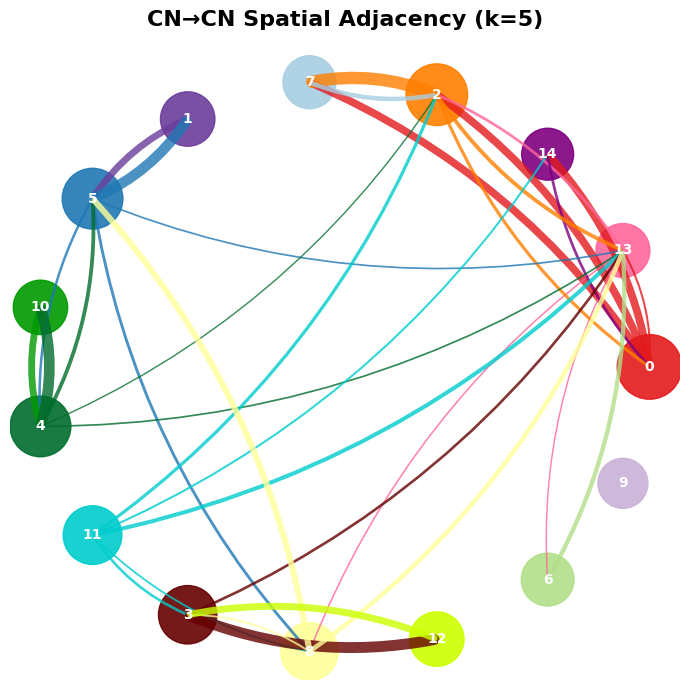

In [43]:
# assume everything up to edge_widths and node_colors is defined as before…

# make a dict for easy lookup
node_color_dict = {n: c for n, c in zip(nodes, node_colors)}

# plot
fig, ax = plt.subplots(figsize=(7,7))

# draw edges (colored by source CN)
for (u, v, d), width in zip(G.edges(data=True), edge_widths):
    w = d['weight']
    if w < threshold:       # skip weak links
        continue
    color = node_color_dict[u]
    ax.annotate(
        "", xy=pos[v], xytext=pos[u],
        arrowprops=dict(
            arrowstyle      = "-",
            color           = color,     # source CN color
            lw              = width,
            alpha           = 0.8,
            connectionstyle = "arc3,rad=0.15"
        )
    )

# draw nodes on top (no border or labels)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    nodelist   = nodes,
    node_size  = node_sizes,
    node_color = node_colors,
    alpha      = 0.9
)

# now add labels at the center of each node
nx.draw_networkx_labels(
    G, pos, 
    labels={n: n for n in nodes},   # map each node to its own name
    font_size=10,
    font_color='white',
    font_weight='bold',
    verticalalignment='center',
    horizontalalignment='center',
    ax=ax
)

ax.set_title("CN→CN Spatial Adjacency (k=5)", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()


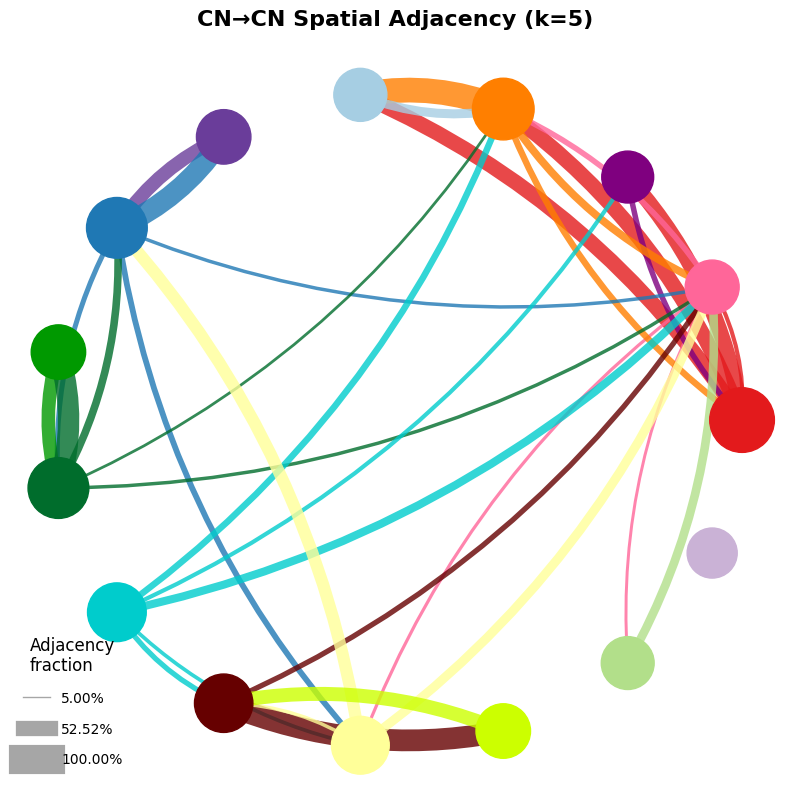

In [41]:
# … previous setup remains the same …
threshold = 0.05
node_color_dict = {n: c for n, c in zip(nodes, node_colors)}

fig, ax = plt.subplots(figsize=(8,8))

# draw tapered “funnels”
for (u, v, d), width in zip(G.edges(data=True), edge_widths):
    w = d['weight']
    if w < threshold:
        continue

    start = pos[u]
    end   = pos[v]
    col   = node_color_dict[u]

    # Tail‐width and head‐width scale off your existing width
    tail_w = width * 2    # adjust these multipliers to taste
    head_w = width * 0.5
    head_l = 3            # a fixed head‐length

    patch = mpl.patches.FancyArrowPatch(
        start, end,
        arrowstyle = f"simple,tail_width={tail_w},head_width={head_w},head_length={head_l}",
        color      = col,
        alpha      = 0.8,
        connectionstyle = "arc3,rad=0.15",
        linewidth  = 0    # linewidth is baked into arrowstyle
    )
    ax.add_patch(patch)

# draw nodes on top
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    nodelist   = nodes,
    node_size  = node_sizes,
    node_color = node_colors,
    alpha      = 1
)

ax.set_title("CN→CN Spatial Adjacency (k=5)", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
#plt.show()

from matplotlib.lines import Line2D

# --- after drawing edges & nodes, before plt.show() ---

# pick some example fractions to illustrate
example_fracs = [
    threshold,                    # your cutoff (e.g. 0.05)
    (weights.min()+weights.max())/2,  # mid‐range
    weights.max()                 # strongest link
]
# compute the corresponding tail_widths you used
example_widths = [1 + 20*((f - weights.min())/(weights.max()-weights.min())) 
                  for f in example_fracs]

# build proxy artists
legend_handles = [
    Line2D([0],[0], color='gray', lw=w, alpha=0.7)
    for w in example_widths
]
legend_labels = [f"{f:.2%}" for f in example_fracs]  # format as "5.00%", etc.

ax.legend(
    legend_handles, legend_labels,
    title="Adjacency\nfraction",
    loc="lower left",
    frameon=False,
    labelspacing=1.2,
    title_fontsize=12
)

fig.savefig("../plots/cn_adj_plot.svg", format="svg", bbox_inches="tight")

plt.show()